## Modelling depression risks among students

This dataset was obtained from [Kaggle]()

In [1]:
import pandas as pd


In [2]:
df=pd.read_csv('student_depression_dataset.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

### Checking the distribution of target variable

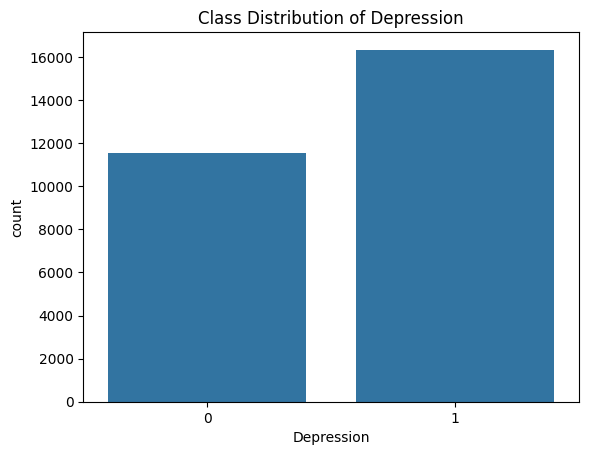

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='Depression')
plt.title("Class Distribution of Depression")
plt.show()

This means that majority of people in the dataset have depression.

### Checking for nulls in dataset

In [5]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

### Checking for correlation between the target and numeric variables

In [6]:
num_df = df.select_dtypes(include=['int64','float64'])
num_df.corr()['Depression'].sort_values(ascending=False)

Depression            1.000000
Academic Pressure     0.474835
Work/Study Hours      0.208563
CGPA                  0.022210
id                    0.000923
Work Pressure        -0.003351
Job Satisfaction     -0.003482
Study Satisfaction   -0.167971
Age                  -0.226422
Name: Depression, dtype: float64

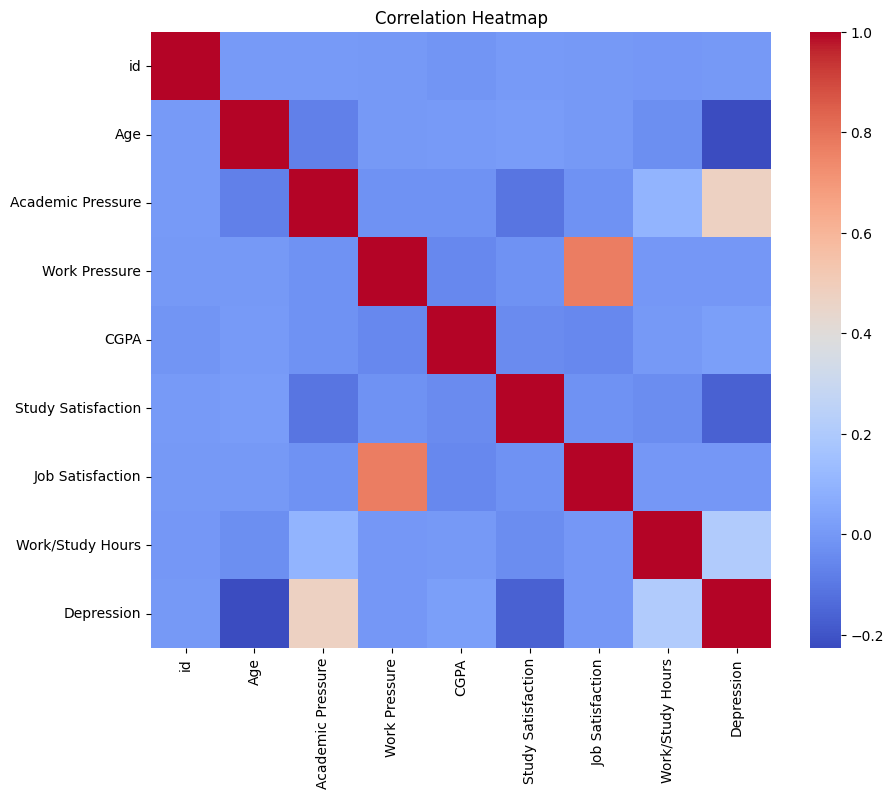

In [7]:
# Visualizing the correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Academic Pressure** seems to be the top variable correlating with positive depression

### Checking for correlation between the targer and catrgorical columns

In [8]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df.groupby(col)['Depression'].mean().sort_values(ascending=False))


--- Gender ---
Gender
Male      0.586287
Female    0.584507
Name: Depression, dtype: float64

--- City ---
City
M.Com                   1.000000
Vaanya                  1.000000
Mira                    1.000000
Nalini                  1.000000
Khaziabad               1.000000
Saanvi                  1.000000
Gaurav                  1.000000
Harsh                   1.000000
Mihir                   1.000000
3.0                     1.000000
Bhavna                  1.000000
Ahmedabad               0.672976
Hyderabad               0.669403
Patna                   0.631579
Rajkot                  0.626225
Bhopal                  0.619914
Delhi                   0.609375
Bangalore               0.608866
Kolkata                 0.608818
Indore                  0.604977
Meerut                  0.597576
Chennai                 0.596610
Kalyan                  0.594904
Thane                   0.590869
Faridabad               0.587852
Ludhiana                0.582358
Surat                   0.579

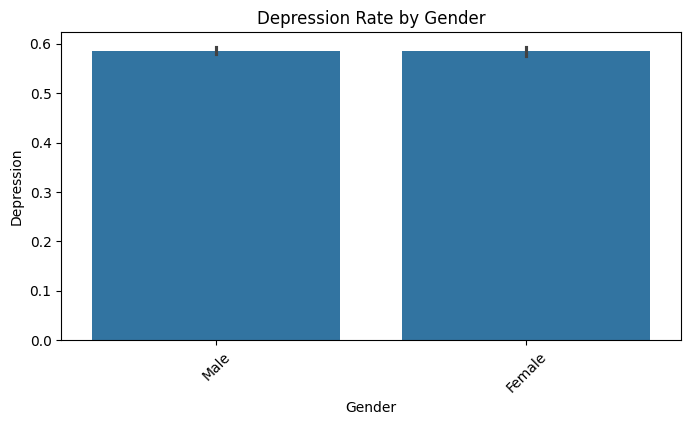

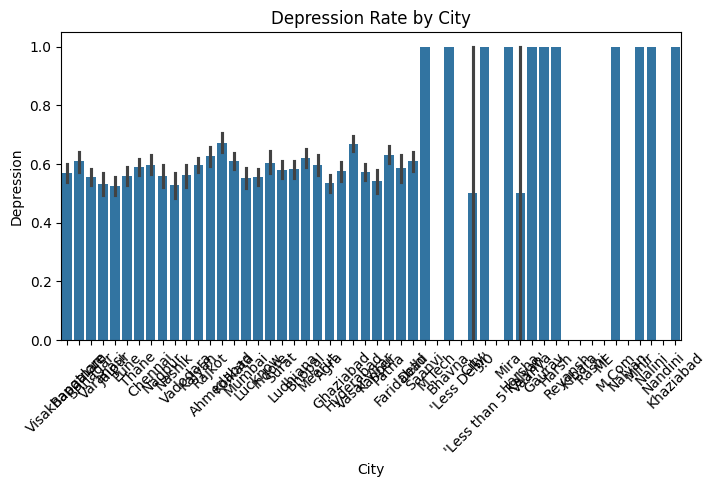

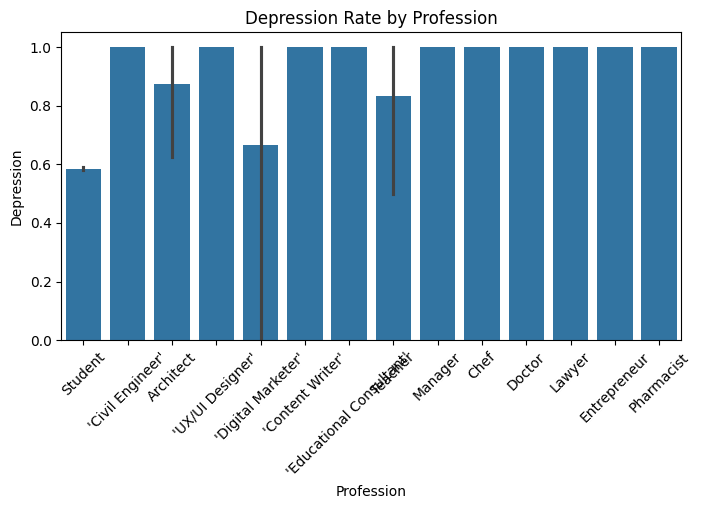

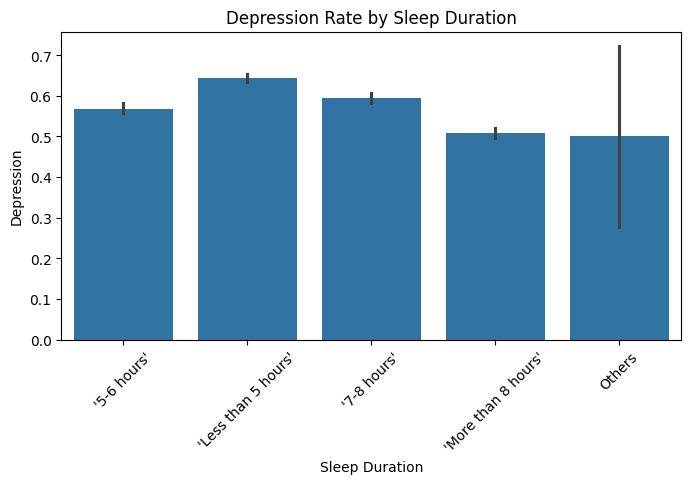

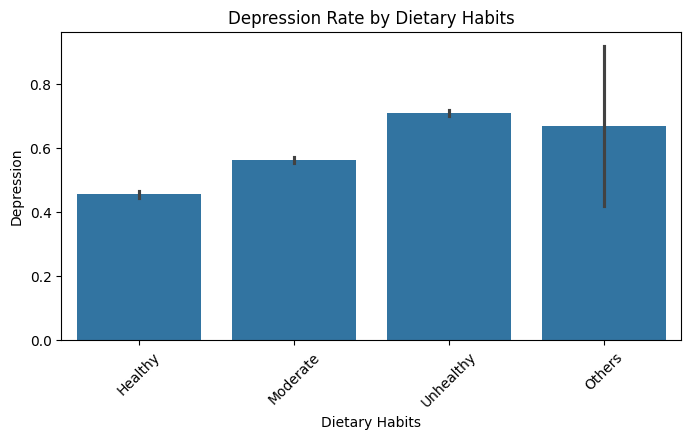

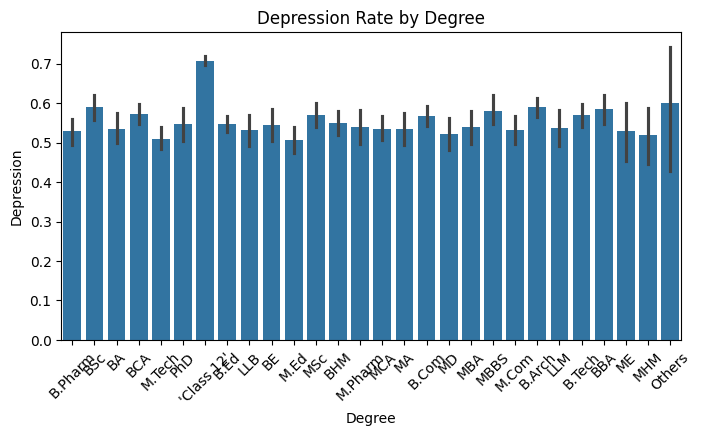

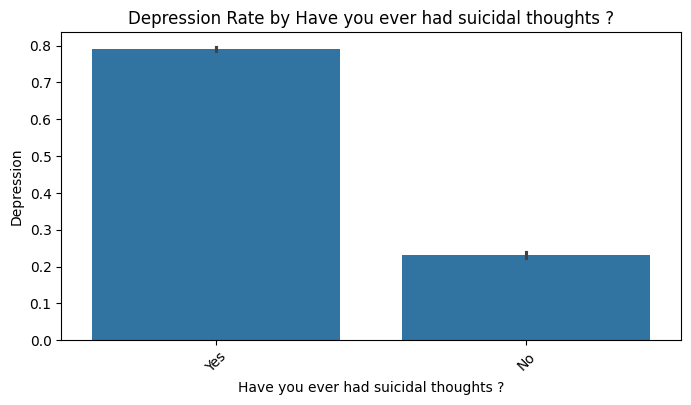

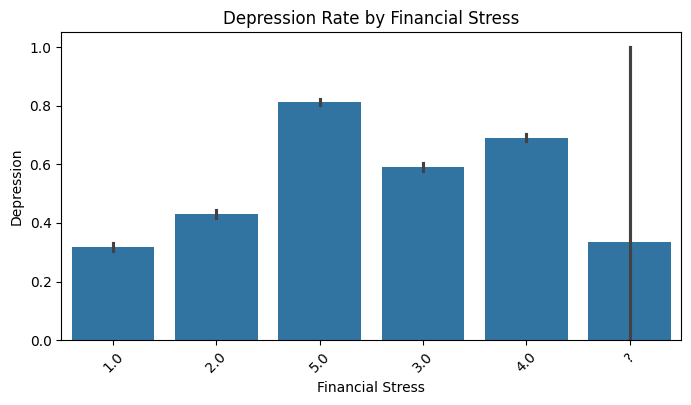

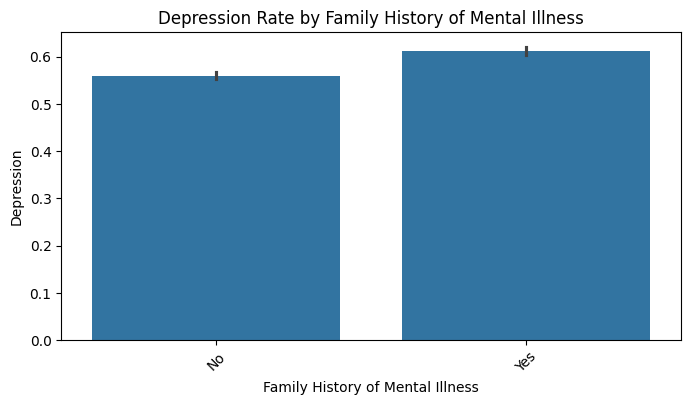

In [9]:
# Visualize the correlation
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(data=df, x=col, y='Depression', estimator=lambda x: sum(x)/len(x))
    plt.title(f"Depression Rate by {col}")
    plt.xticks(rotation=45)
    plt.show()


### Chi-square test for categoricals

In [10]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    table = pd.crosstab(df[col], df['Depression'])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{col}: p-value = {p}")


Gender: p-value = 0.7737273485068406
City: p-value = 1.4718284584775762e-17
Profession: p-value = 0.35385931991393826
Sleep Duration: p-value = 1.065310789284643e-58
Dietary Habits: p-value = 1.9624854819352487e-260
Degree: p-value = 5.125450008521773e-95
Have you ever had suicidal thoughts ?: p-value = 0.0
Financial Stress: p-value = 0.0
Family History of Mental Illness: p-value = 4.9849805086059e-19


A p-value<0.05 indicates a statistically significant relationship. p>=0.05 indicates no evidence of relationship with target variable. 
From the above results, the following variables seem to have a genuine relationship with the target variable.

- City
- Sleep duration
- Dietary Habits
- Degree
- Family History of mental illness


In [11]:
# unique entries in 'city'
df['City'].nunique()

52

### Encode Categoricals

In [12]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
df_encoded.drop(columns='City')

le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

### Train Random Forest model

In [13]:
from sklearn.ensemble import RandomForestClassifier

X = df_encoded.drop('Depression', axis=1)
y = df_encoded['Depression']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

Have you ever had suicidal thoughts ?    0.222967
Academic Pressure                        0.161819
Financial Stress                         0.088432
id                                       0.078427
Age                                      0.073812
CGPA                                     0.073680
City                                     0.061399
Work/Study Hours                         0.061005
Degree                                   0.053412
Study Satisfaction                       0.037296
Dietary Habits                           0.032965
Sleep Duration                           0.028567
Gender                                   0.013212
Family History of Mental Illness         0.012620
Profession                               0.000325
Job Satisfaction                         0.000051
Work Pressure                            0.000013
dtype: float64

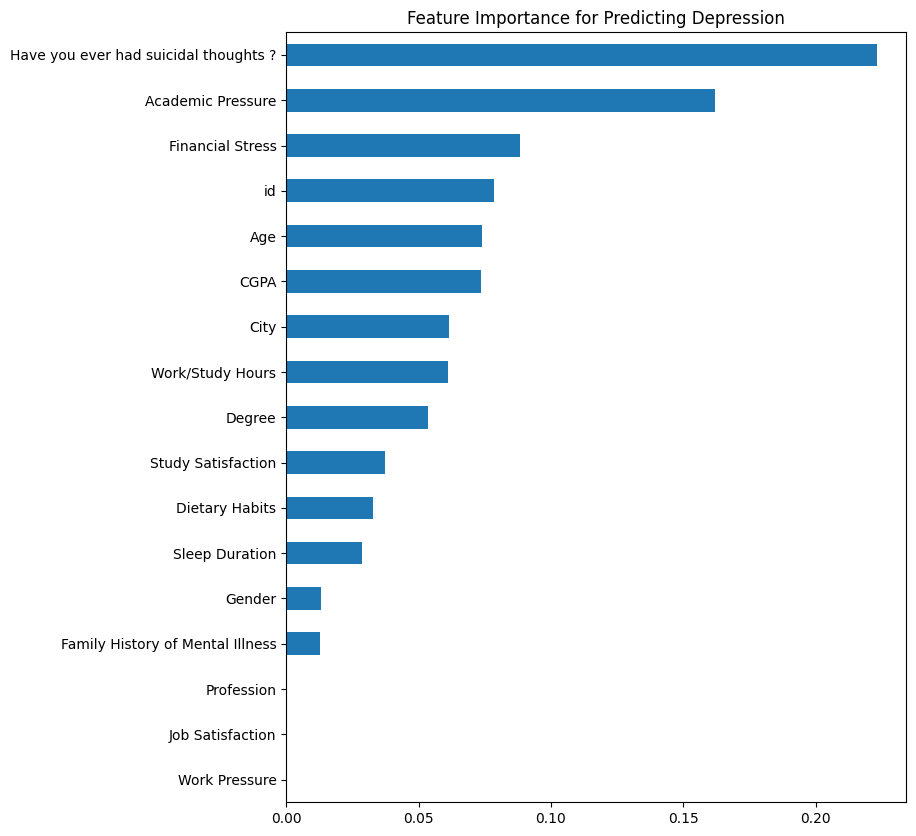

In [14]:
# Visualize the feature importances
import matplotlib.pyplot as plt

importances.sort_values().plot(kind='barh', figsize=(8,10))
plt.title("Feature Importance for Predicting Depression")
plt.show()

### Correlation Heatmap of encoded dataframe

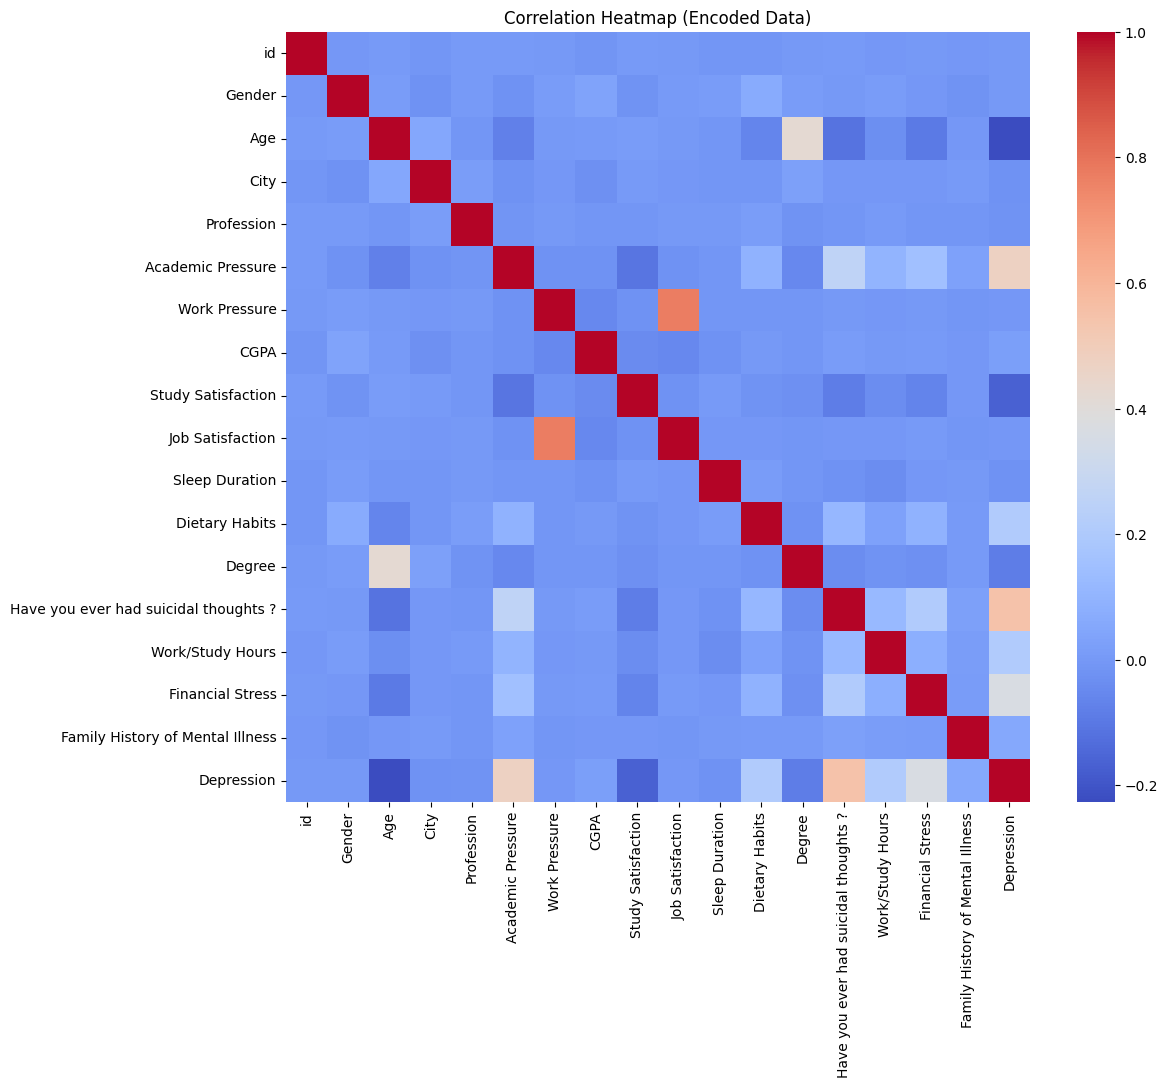

In [15]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap (Encoded Data)")
plt.show()

According to the heatmap, the variables that have a positive correlation with the target variable are:

- Academic Pressure
- have you ever had siucidal thoughts
- Financial stress
- Dietary Habits


### Building a baseline model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2343
           1       0.84      0.86      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581



### Checking for class imbalance

In [18]:
df['Depression'].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [19]:
df['Depression'].value_counts(normalize=True) * 100

Depression
1    58.549873
0    41.450127
Name: proportion, dtype: float64

Since the percentages of yes and no add up to <100, there is no class imbalance.

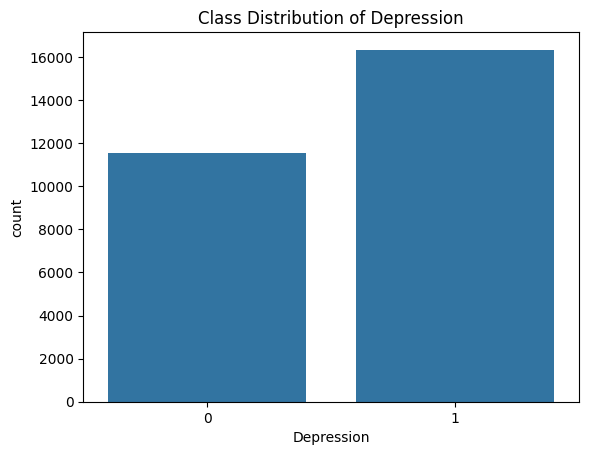

In [20]:
# bar chart to show the imbalance

sns.countplot(data=df, x='Depression')
plt.title("Class Distribution of Depression")
plt.show()

### Check imbalances after the train test split

In [21]:
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)
print("Train distribution:", dict(zip(unique, counts)))

unique, counts = np.unique(y_test, return_counts=True)
print("Test distribution:", dict(zip(unique, counts)))

Train distribution: {0: 9222, 1: 13098}
Test distribution: {0: 2343, 1: 3238}


In [22]:
# Model metrics

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79      2343
           1       0.84      0.86      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581



There was no class imbalance even after splitting the dataset. The high precision and recall for the class 1 in the classification report shows that the model is learning properly. 

### Hyperparameter tuning to optimize model performance

In [24]:
from sklearn.model_selection import GridSearchCV

params = {'n_estimators': [100, 200, 300], 
          'max_depth': [None, 10, 20, 30], 
          'min_samples_split': [2, 5, 10] }

grid = GridSearchCV(model,
                    param_grid= params,
                    cv=3,
                    scoring='f1')

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}


### Retraining the model using the best params

In [25]:
bst_prm = grid.best_params_
best_model = RandomForestClassifier(**bst_prm, random_state=42)
best_model.fit(X_train,y_train)

RandomForestClassifier(min_samples_split=5, n_estimators=300, random_state=42)

### Evaluating and Comparing performance

In [39]:
from sklearn.metrics import confusion_matrix, roc_auc_score as rauc

bm_pred = best_model.predict(X_test)

print('Tunned Model Classification Report \n',classification_report(y_test, bm_pred))
print('Baseline Model Classification Report \n',classification_report(y_test, preds))

bm_rauc = rauc(y_test, best_model.predict_proba(X_test)[:,1])
print("Tunned Model ROC-AUC: \n", np.round(bm_rauc*100,3),'%')
m_rauc = rauc(y_test, model.predict_proba(X_test)[:,1])
print('Baseline Model ROC-AUC: \n', np.round(m_rauc*100,3),'%')

Tunned Model Classification Report 
               precision    recall  f1-score   support

           0       0.81      0.77      0.79      2343
           1       0.84      0.87      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.83      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581

Baseline Model Classification Report 
               precision    recall  f1-score   support

           0       0.80      0.78      0.79      2343
           1       0.84      0.86      0.85      3238

    accuracy                           0.83      5581
   macro avg       0.82      0.82      0.82      5581
weighted avg       0.83      0.83      0.83      5581

Tunned Model ROC-AUC: 
 90.85 %
Baseline Model ROC-AUC: 
 90.614 %


After tuning the model, the precision for class 1 remained the same, while recall increased by 0.01. The accuracy of the tuned model is similar to the baseline model. However, the tuned model has a slightly higher roc-auc than the baseline model.